In [6]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch. optim as optim

In [2]:
trainset = torchvision.datasets.FashionMNIST(
    root='../chao08/data', train=True,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 21.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 346kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.31MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.6MB/s]


In [3]:
batch_size=4
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

In [5]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
8


In [7]:
#이미지 데이터 출력 전처리
def imshow(img,title):
  plt.figure(figsize=(batch_size * 4, 4)) # 출력할 개별 이미지의 크기 지정
  plt.axis('off')
  plt.imshow(np.transpose(img, (1, 2, 0)))
  plt.title(title)
  plt.show()


In [8]:
#이미지 데이터 출력 함수
def show_batch_images(dataloader):
  images, labels = next(iter(dataloader))
  img=torchvision.utils.make_grid(images)
  imshow(img, title=[str(x.item()) for x in labels])
  return images, labels


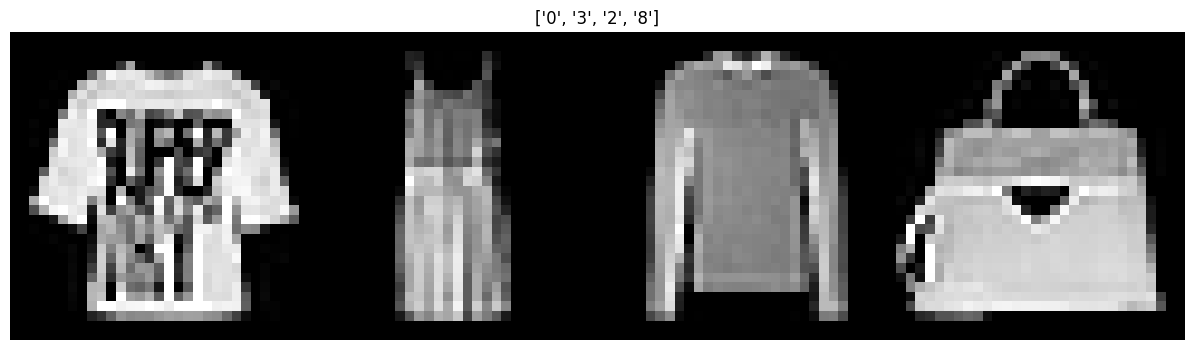

In [9]:
images, labesl = show_batch_images(trainloader) #이미지 출력

In [10]:
#배치 정규화가 적용되지 않은 네트워크
class NormalNet(nn.Module):
  def __init__(self):
    super(NormalNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48),
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.ReLU(),
        nn.Linear(24, 10)
    )
  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

In [18]:
#배치 정규화가 포함된 네트워크
class BNNet(nn.Module):
  def __init__(self):
    super(BNNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48),
        nn.BatchNorm1d(48),
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.BatchNorm1d(24),
        nn.ReLU(),
        nn.Linear(24, 10)
    )
  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

In [12]:
#배치 정규화가 적용되지 않은 모델 선언
model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [21]:
#배치 정규화가 적용된 모델 선언
model_bn = BNNet()
print(model)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [14]:
#데이터셋 메모리로 불러오기
batch_size = 512
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

In [16]:
#모델에서 사용할 옵티마니저와 손실 함수 지정
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
opt_bn = optim.SGD(model.parameters(), lr=0.01)

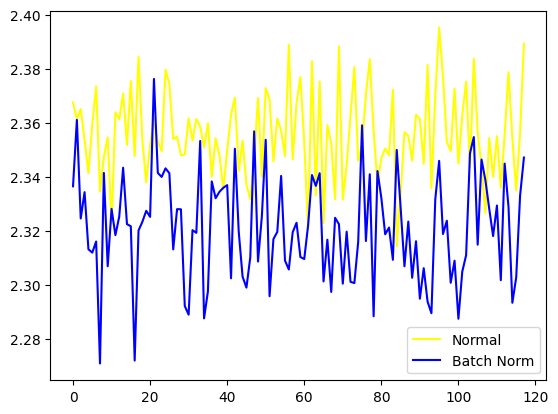

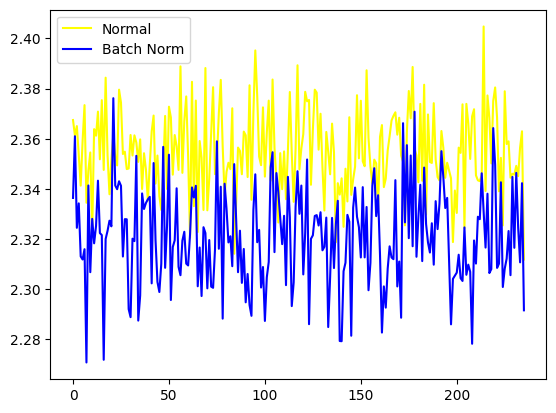

In [22]:
loss_arr=[]
loss_bn_arr=[]
max_epochs=2

for epoch in range(max_epochs):
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    loss.backward()
    optimizer.step()

    opt_bn.zero_grad()
    outputs_bn = model_bn(inputs)
    loss_bn = loss_fn(outputs_bn, labels)
    loss_bn.backward()
    opt_bn.step()

    loss_arr.append(loss.item())
    loss_bn_arr.append(loss_bn.item())

  plt.plot(loss_arr, 'yellow', label='Normal')
  plt.plot(loss_bn_arr, 'blue', label='Batch Norm')
  plt.legend()
  plt.show()

In [23]:
#데이터셋의 분포를 출력하기 위한 전처리
N = 50
noise = 0.3

x_train = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_train = x_train + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

x_test = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_test = x_test + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

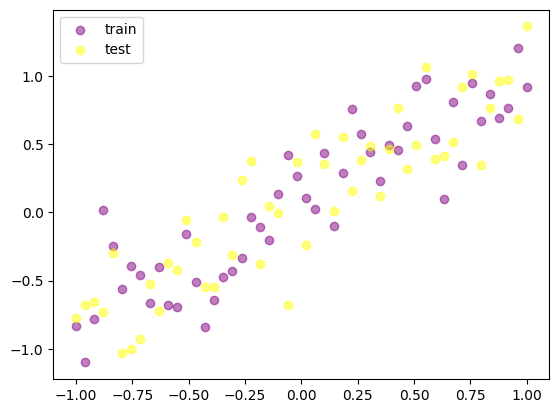

In [24]:
plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple',
            alpha=0.5, label='train')
plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
            alpha=0.5, label='test')
plt.legend()
plt.show()

In [27]:
#드롭아웃을 위한 모델 생성
N_h = 100
model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
) #드롭아웃이 적용되지 않은 모델
model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
) #드롭아웃이 적용된 모델


In [28]:
#옵티마이저와 손실 함수 지정
opt = torch.optim.Adam(model.parameters(), lr=0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr=0.01)
loss_fn = torch.nn.MSELoss()

/tmp/ipykernel_4434/1121148411.py:32: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %


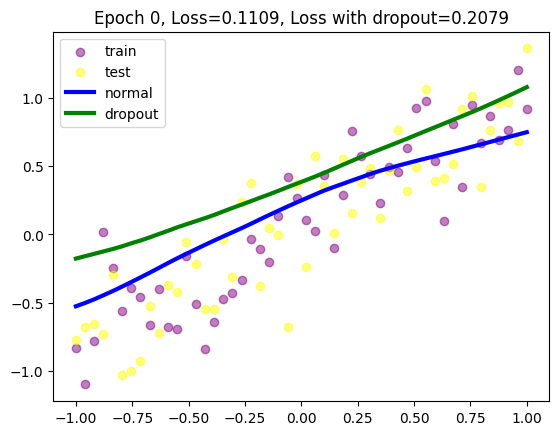

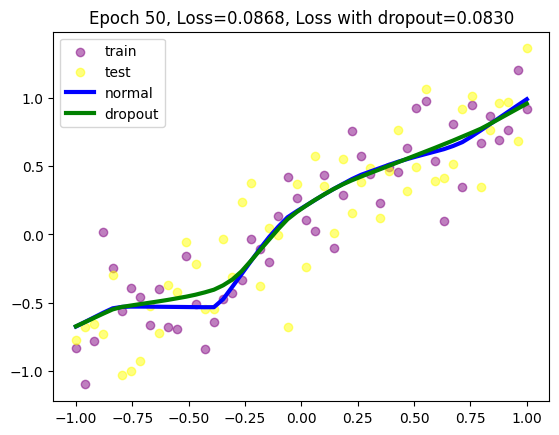

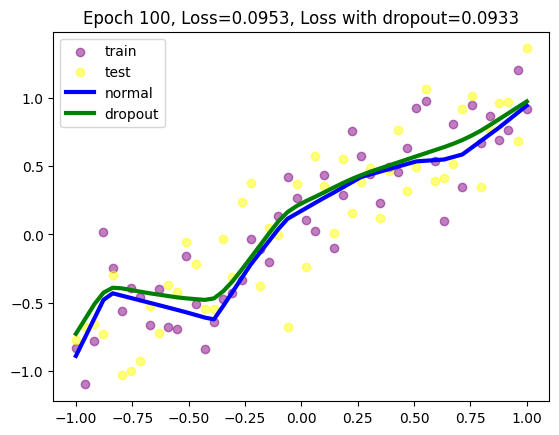

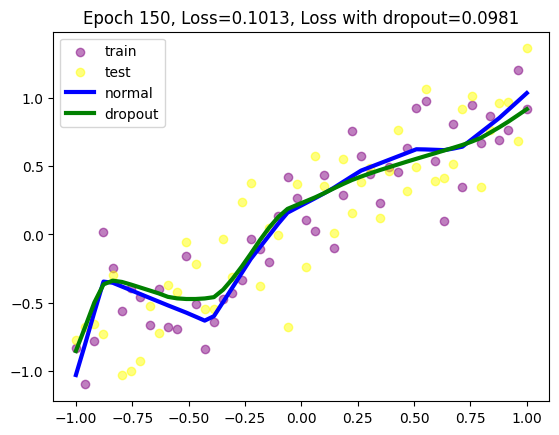

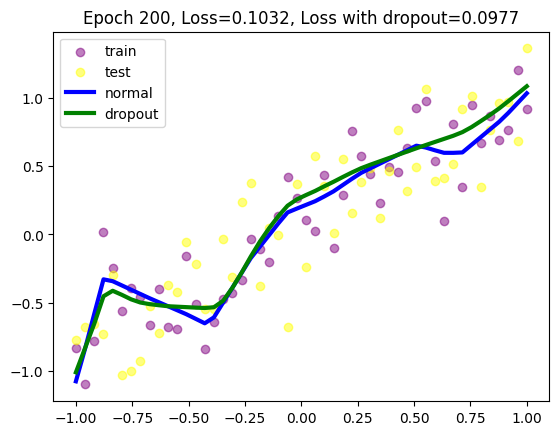

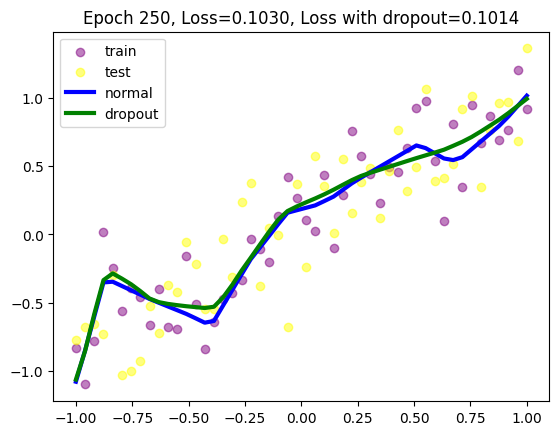

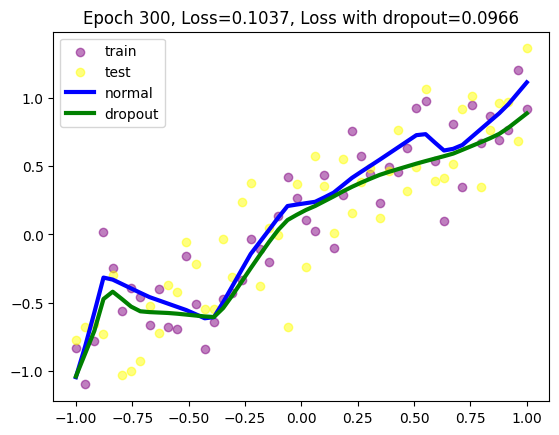

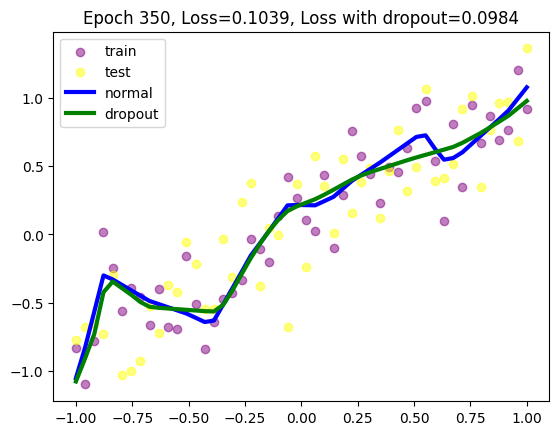

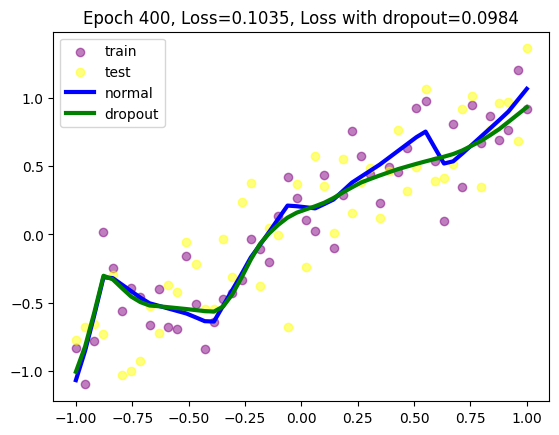

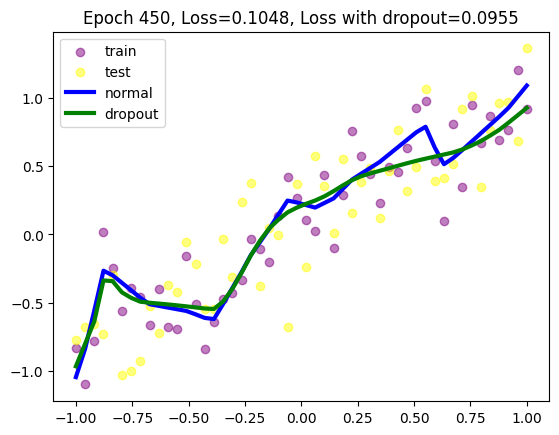

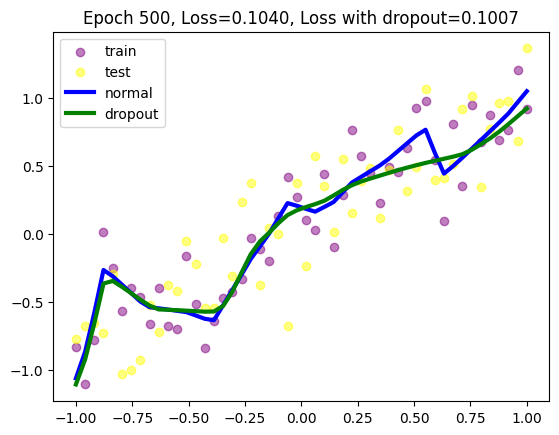

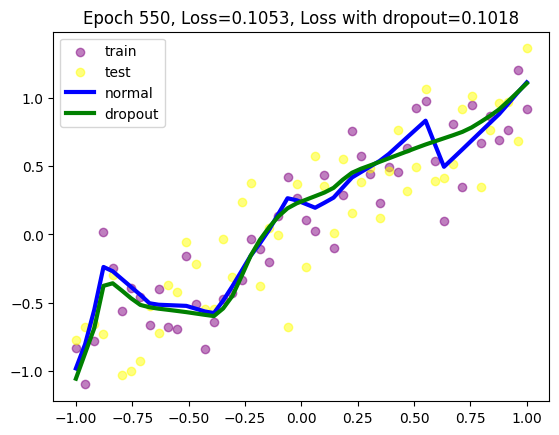

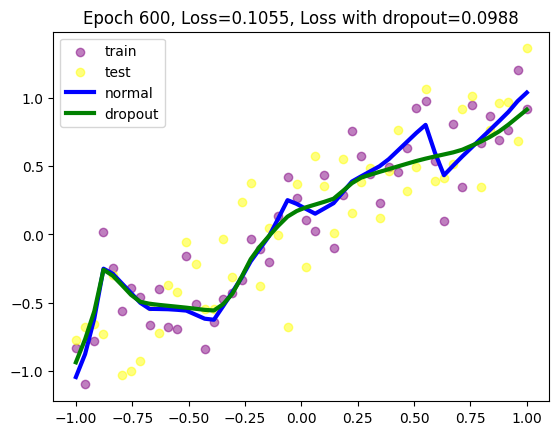

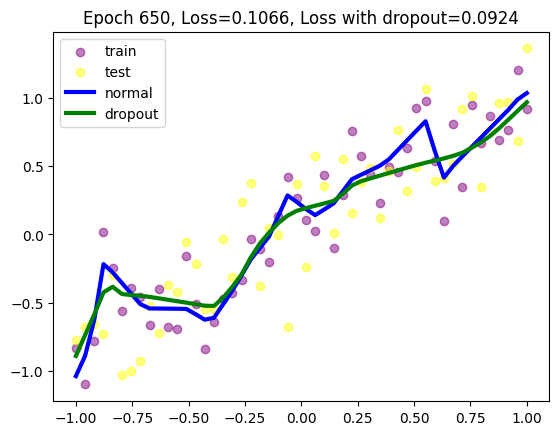

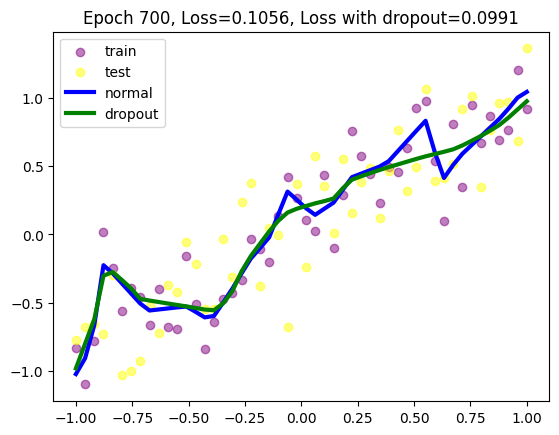

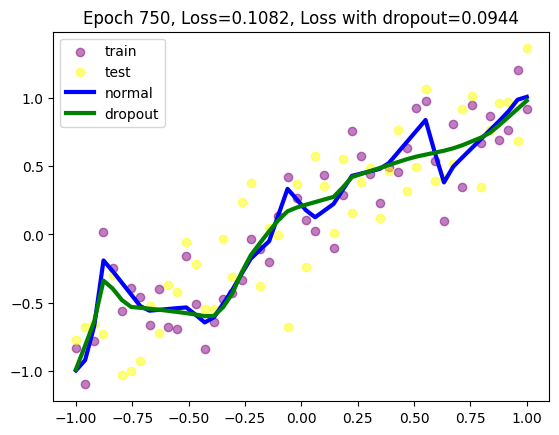

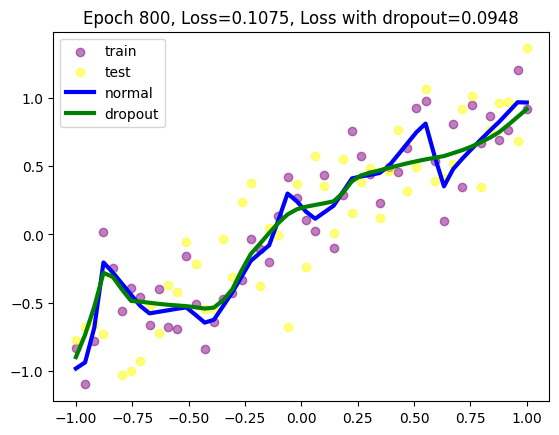

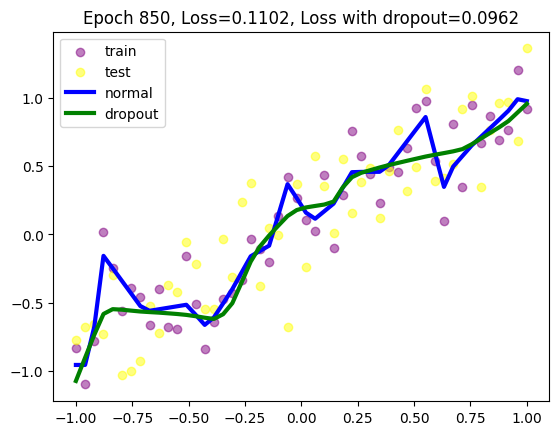

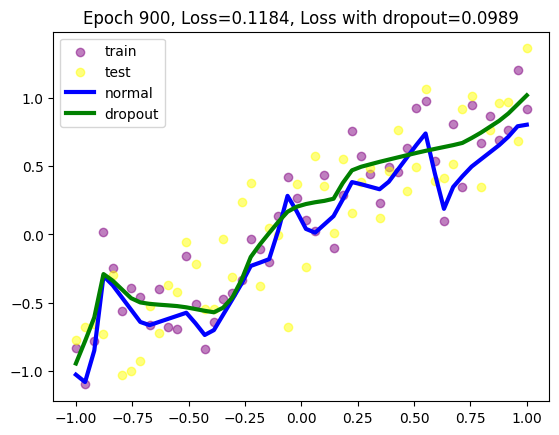

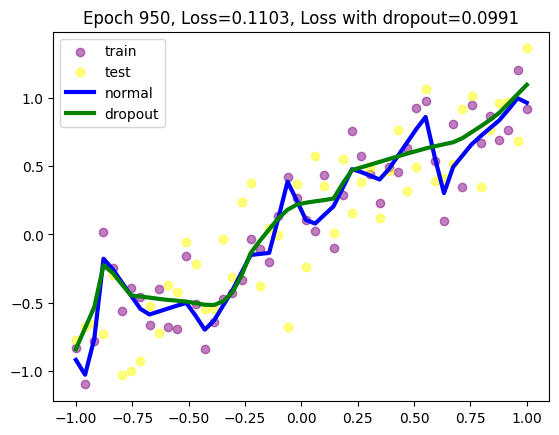

In [30]:
#모델 학습
max_epochs = 1000
for epoch in range(max_epochs):
  pred=model(x_train)
  loss=loss_fn(pred, y_train)
  opt.zero_grad()
  loss.backward()
  opt.step()

  pred_dropout = model_dropout(x_train)
  loss_dropout = loss_fn(pred_dropout, y_train)
  opt_dropout.zero_grad()
  loss_dropout.backward()
  opt_dropout.step()

  if epoch % 50 == 0:
    model.eval()
    model_dropout.eval()

    test_pred = model(x_test)
    test_loss = loss_fn(test_pred, y_test)

    test_pred_dropout = model_dropout(x_test)
    test_loss_dropout = loss_fn(test_pred_dropout, y_test)

    plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple',
                alpha=0.5, label='train')
    plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
                alpha=0.5, label='test')
    plt.plot(x_test.data.numpy(), test_pred.data.numpy(), 'b-', lw=3, label='normal')
    plt.plot(x_test.data.numpy(), test_pred_dropout.data.numpy(), 'g-', lw=3, label='dropout')
    plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %
              (epoch, test_loss, test_loss_dropout))
    plt.legend()
    model.train()
    model_dropout.train()
    plt.pause(0.05)

##조기종료를 이용한 성능 최적화

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms, datasets

import matplotlib
import matplotlib.pyplot as plt
import time
import argparse
from tqdm import tqdm
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [32]:
#데이터셋 전처리
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
#데이터셋 가져오기
train_dataset = torchvision.datasets.ImageFolder(
    root=r'/content/drive/MyDrive/Euron/archive/train',
    transform=train_transform
)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True
)

val_dataset = torchvision.datasets.ImageFolder(
    root=r'/content/drive/MyDrive/Euron/archive/test',
    transform=val_transform
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=32, shuffle=False,
)

In [40]:
#모델 생성
def resnet50(pretrained=True, requires_grad=False):
  model = models.resnet50(progress=True, pretrained=pretrained)
  if requires_grad == False:
    for param in model.parameters():
      param.requires_grad = False
  elif requires_grad == True:
    for param in model.parameters():
      param.requires_grad = True
  model.fc = nn.Linear(2048, 2)
  return model

In [41]:
#학습률 감소
class LRScheduler():
  def __init__(self, optimizer, patience=5, min_lr=1e-6, factor=0.5):
    self.optimizer = optimizer
    self.patience = patience
    self.min_lr = min_lr
    self.factor = factor
    self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        self.optimizer,
        mode='min',
        patience=self.patience,
        factor=self.factor,
        min_lr=self.min_lr,
        verbose=True
    )
  def __call__(self, val_loss):
    self.lr_scheduler.step(val_loss)

In [43]:
#조기 종류
class EarlyStopping():
  def __init__(self, patience=5, verbose=False, delta=0, path= '/content/drive/MyDrive/Euron/archive/data/checkpoint.pt'):
    self.patience=patience
    self.verbose=verbose
    self.counter=0
    self.best_score=None
    self.early_stop=False
    self.val_loss_min=np.Inf
    self.delta = delta
    self.path=path

  def __call__(self, val_loss, model):
    score = -val_loss
    if self.best_score is None:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
    elif score < self.best_score + self.delta:
      self.counter +=1
      print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
      if self.counter >= self.patience:
        self.early_stop = True
    else:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
      self.counter=0

  def save_checkpoint(self, val_loss, model):
    if self.verbose:
      print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model ...')
      torch.save(model.state_dict(), self.path)
      self.val_loss_min = val_loss

In [46]:
import argparse

#인수 값 지정
parser = argparse.ArgumentParser()
parser.add_argument('--lr-scheduler', dest='lr_scheduler', action='store_true')
parser.add_argument('--early-stopping', dest = 'early_stopping', action='store_true')
args = vars(parser.parse_args(args=[]))

In [49]:
import torchvision.models as models
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Computation device: {device} \n")
model = models.resnet50(pretrained=True).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.")

Computation device: cpu 



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 121MB/s]


25,557,032 total parameters.
25,557,032 training parameters.


In [65]:
#옵티마이저와 손실 함수 지정
lr = 0.001
epochs = 10
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

In [51]:
#오차, 정확도 및 모델의 이름에 대한 문자열
loss_plot_name = 'loss'
acc_plot_name = 'accuracy'
model_name = 'model'

In [52]:
#오차, 정확도 및 모델의 이름에 대한 문자열
if args['lr_scheduler']:
  print('INFO: Initializing learning rate scheduler')
  lr_scheduler = LRScheduler(optimizer)
  loss_plot_name = 'lrs_loss'
  acc_plot_name = 'lrs_accuracy'
  model_name = 'lrs_model'
if args['early_stopping']:
  print('INFO: Initializing early stopping')
  early_stopping = EarlyStopping()
  loss_plot_name = 'es_loss'
  acc_plot_name = 'es_accuracy'
  model_name = 'es_model'

In [57]:
#모델 학습 함수
from tqdm import tqdm
def training(model, train_dataloader, train_dataset, optimizer, criterion):
  model.train()
  print('Training')
  train_running_loss = 0.0
  train_running_correct = 0
  counter=0
  total=0
  prog_bar = tqdm(enumerate(train_dataloader), total=int(len(train_dataset)/train_dataloader.batch_size))
  for i, data in prog_bar:
    counter += 1
    data, target = data[0].to(device), data[1].to(device)
    total+=target.size(0)
    optimizer.zero_grad()
    outputs=model(data)
    loss=criterion(outputs, target)
    train_running_loss += loss.item()
    _, preds = torch.max(outputs.data, 1)
    train_running_correct += (preds == target).sum().item()
    loss.backward()
    optimizer.step()

  train_loss = train_running_loss / counter
  train_accuracy = 100. * train_running_correct / total
  return train_loss, train_accuracy

In [63]:
import torch
from tqdm import tqdm
def validate(model, val_dataloader, val_dataset, criterion):
  model.eval()
  print('Validation')
  val_running_loss = 0.0 # Changed from valid_running_loss
  val_running_correct = 0 # Changed from valid_running_correct
  counter=0
  total=0
  prog_bar = tqdm(enumerate(val_dataloader), total=int(len(val_dataset)/val_dataloader.batch_size))
  with torch.no_grad():
    for i, data in prog_bar:
      counter += 1
      data, target = data[0].to(device), data[1].to(device)
      total+=target.size(0)
      outputs = model(data)
      loss = criterion(outputs, target)

      val_running_loss += loss.item()
      _, preds = torch.max(outputs.data, 1)
      val_running_correct += (preds == target).sum().item()

    val_loss = val_running_loss / counter
    val_accuracy = 100. * val_running_correct / total
    return val_loss, val_accuracy

In [ ]:
import time

#모델 학습
train_loss, train_accuracy = [], []
val_loss, val_accuracy = [], []
start = time.time()
for epoch in range(epochs):
  print(f"Epoch {epoch+1} of {epochs}")
  train_epoch_loss, train_epoch_accuracy = training(
      model, train_dataloader, train_dataset, optimizer, criterion)
  val_epoch_loss, val_epoch_accuracy = validate(
      model, val_dataloader, val_dataset, criterion)
  train_loss.append(train_epoch_loss)
  train_accuracy.append(train_epoch_accuracy)
  val_loss.append(val_epoch_loss)
  val_accuracy.append(val_epoch_accuracy)
  if args['lr_scheduler']:
    lr_scheduler(val_epoch_loss)
  if args['early_stopping']:
    early_stopping(val_epoch_loss, model)
    if early_stopping.early_stop:
      break
  print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
  print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}")
end = time.time()
print(f"{(end-start)/60:.3f} minutes")

Epoch 1 of 10
Training


  0%|          | 0/15 [00:00<?, ?it/s]

In [ ]:
#모델 학습 결과 출력
print("Saving loss and accuracy plots...")
plt.figure(figsize=(10, 7))
plt.plot(train_accuracy, color='green', label='train accuracy')
plt.plot(val_accuracy, color='blue', label='validataion accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f"/content/drive/MyDrive/Euron/archive/data/{acc_plot_name}.png")
plt.show()
plt.figure(figsize=(10, 7))
plt.plot(train_loss, color='orange', label='train loss')
plt.plot(val_loss, color='red', label='validataion loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"/content/drive/MyDrive/Euron/archive/data/{loss_plot_name}.png")
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f"/content/drive/MyDrive/Euron/archive/data/{model_name}.pt")
print('TRAINING COMPLETE')
